# EdgeTwin AI — Predictive Maintenance
## 01_Data_Understanding.ipynb

**Step 2: Data Understanding**
**Step 3: Data Cleaning**

Dataset: `predictive_maintenance_dataset.csv` (Industrial IoT sensor data — CNC machines, motors, pumps, compressors, conveyors)


---
## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


Matplotlib is building the font cache; this may take a moment.


---
## 1. Load Dataset

In [6]:
# Load the raw dataset
df = pd.read_csv(r'D:\Project\EdgeTwin-AI\data\raw\predictive_maintenance_dataset.csv')

# Keep an untouched copy of the raw data for comparison later
df_raw = df.copy()

print(f"Dataset loaded successfully. Shape: {df.shape}")
df.head()

Dataset loaded successfully. Shape: (10000, 17)


,Machine_ID,Timestamp,Machine_Type,Air_Temperature_C,Process_Temperature_C,Rotational_Speed_RPM,Torque_Nm,Vibration_mm_s,Pressure_bar,Current_A,Voltage_V,Tool_Wear_Min,Operating_Hours,Failure_Type,Machine_Failure,Sensor_Batch_Code,Checksum_Flag
0,PMP-1016,2024-03-02 10:08:00,Pump,28.68,39.66,1544.0,42.00,3.258,6.80,14.63,419.1,41.8,11447.1,No Failure,0,BATCH_3183,OK
1,CNC-1032,2024-03-19 15:24:00,CNC_Machine,26.34,36.74,1866.0,49.10,3.157,7.24,16.73,407.5,98.6,13154.1,No Failure,0,BATCH_1834,OK
2,CMP-1001,2024-03-02 06:30:00,Compressor,19.54,29.82,1893.0,35.47,2.760,7.34,11.43,408.0,165.2,14200.3,No Failure,0,BATCH_9584,OK
3,PMP-1019,2024-05-04 12:01:00,Pump,24.93,33.20,1500.0,25.58,2.662,4.73,14.61,429.7,222.5,4206.0,No Failure,0,BATCH_8777,OK
4,CMP-1042,2024-01-17 06:18:00,Compressor,25.29,33.44,1245.0,38.87,3.936,6.47,13.85,NaN,62.7,13340.1,No Failure,0,BATCH_7838,OK


---
# STEP 2: Data Understanding

Goal: Understand the structure, data types, ranges, and quality issues in the raw dataset before any cleaning is performed.


## 2.1 Basic Dataset Information

In [7]:
print("Shape of dataset (rows, columns):", df.shape)
print("\nColumn names:\n", list(df.columns))


Shape of dataset (rows, columns): (10000, 17)

Column names:
 ['Machine_ID', 'Timestamp', 'Machine_Type', 'Air_Temperature_C', 'Process_Temperature_C', 'Rotational_Speed_RPM', 'Torque_Nm', 'Vibration_mm_s', 'Pressure_bar', 'Current_A', 'Voltage_V', 'Tool_Wear_Min', 'Operating_Hours', 'Failure_Type', 'Machine_Failure', 'Sensor_Batch_Code', 'Checksum_Flag']


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Machine_ID             10000 non-null  object 
 1   Timestamp              10000 non-null  object 
 2   Machine_Type           9510 non-null   object 
 3   Air_Temperature_C      9194 non-null   float64
 4   Process_Temperature_C  9865 non-null   float64
 5   Rotational_Speed_RPM   8976 non-null   float64
 6   Torque_Nm              9870 non-null   float64
 7   Vibration_mm_s         9587 non-null   float64
 8   Pressure_bar           9251 non-null   float64
 9   Current_A              9903 non-null   float64
 10  Voltage_V              9324 non-null   float64
 11  Tool_Wear_Min          9729 non-null   float64
 12  Operating_Hours        9787 non-null   float64
 13  Failure_Type           10000 non-null  object 
 14  Machine_Failure        10000 non-null  int64  
 15  Sen

## 2.2 Data Types Overview

In [9]:
dtype_summary = pd.DataFrame({
    'Column': df.columns,
    'Data_Type': df.dtypes.values,
    'Unique_Values': [df[col].nunique() for col in df.columns]
})
dtype_summary


,Column,Data_Type,Unique_Values
0,Machine_ID,object,60
1,Timestamp,object,9584
2,Machine_Type,object,5
3,Air_Temperature_C,float64,1455
4,Process_Temperature_C,float64,1652
5,Rotational_Speed_RPM,float64,957
6,Torque_Nm,float64,3863
7,Vibration_mm_s,float64,3816
8,Pressure_bar,float64,976
9,Current_A,float64,1740


## 2.3 Statistical Summary — Numerical Features

In [10]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Air_Temperature_C,9194.0,25.661139,3.017969,16.120,23.730,25.440,27.2500,41.630
Process_Temperature_C,9865.0,35.720866,3.523044,24.630,33.520,35.430,37.4500,55.830
Rotational_Speed_RPM,8976.0,1543.409537,182.016714,864.000,1424.000,1541.000,1666.0000,2250.000
Torque_Nm,9870.0,41.006506,11.480612,4.830,33.630,40.430,47.6100,106.130
Vibration_mm_s,9587.0,2.620705,1.207071,0.003,1.856,2.544,3.2555,11.861
Pressure_bar,9251.0,5.543145,1.832794,0.010,4.320,5.510,6.7100,14.790
Current_A,9903.0,12.009520,3.674253,0.000,9.590,12.020,14.3800,29.340
Voltage_V,9324.0,415.063996,15.573622,311.600,406.700,415.000,423.3000,525.800
Tool_Wear_Min,9729.0,135.850735,76.835128,0.000,69.000,138.400,203.4000,260.000
Operating_Hours,9787.0,10013.625105,5799.922762,1.900,4986.350,10007.500,15125.0000,19994.300


## 2.4 Statistical Summary — Categorical Features

In [11]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

df[categorical_cols].describe().T


Categorical columns: ['Machine_ID', 'Timestamp', 'Machine_Type', 'Failure_Type', 'Sensor_Batch_Code', 'Checksum_Flag']


,count,unique,top,freq
Machine_ID,10000,60,CMP-1042,188
Timestamp,10000,9584,2024-04-14 12:19:00,3
Machine_Type,9510,5,Compressor,2726
Failure_Type,10000,6,No Failure,8901
Sensor_Batch_Code,9303,5960,BATCH_3666,7
Checksum_Flag,7405,1,OK,7405


## 2.5 Unique Values in Key Categorical Columns

In [12]:
print("Machine_Type value counts:")
print(df['Machine_Type'].value_counts(dropna=False))

print("\nFailure_Type value counts:")
print(df['Failure_Type'].value_counts(dropna=False))

print("\nMachine_Failure value counts:")
print(df['Machine_Failure'].value_counts(dropna=False))


Machine_Type value counts:
Machine_Type
Compressor     2726
Pump           2366
CNC_Machine    1881
Conveyor       1571
Motor           966
NaN             490
Name: count, dtype: int64

Failure_Type value counts:
Failure_Type
No Failure                  8901
Heat Dissipation Failure     337
Overstrain Failure           280
Power Failure                199
Tool Wear Failure            174
Random Failure               109
Name: count, dtype: int64

Machine_Failure value counts:
Machine_Failure
0    8901
1    1099
Name: count, dtype: int64


## 2.6 Missing Values Overview

In [13]:
missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Percentage', ascending=False)

missing_summary[missing_summary['Missing_Count'] > 0]


,Missing_Count,Missing_Percentage
Checksum_Flag,2595,25.95
Rotational_Speed_RPM,1024,10.24
Air_Temperature_C,806,8.06
Pressure_bar,749,7.49
Sensor_Batch_Code,697,6.97
Voltage_V,676,6.76
Machine_Type,490,4.90
Vibration_mm_s,413,4.13
Tool_Wear_Min,271,2.71
Operating_Hours,213,2.13


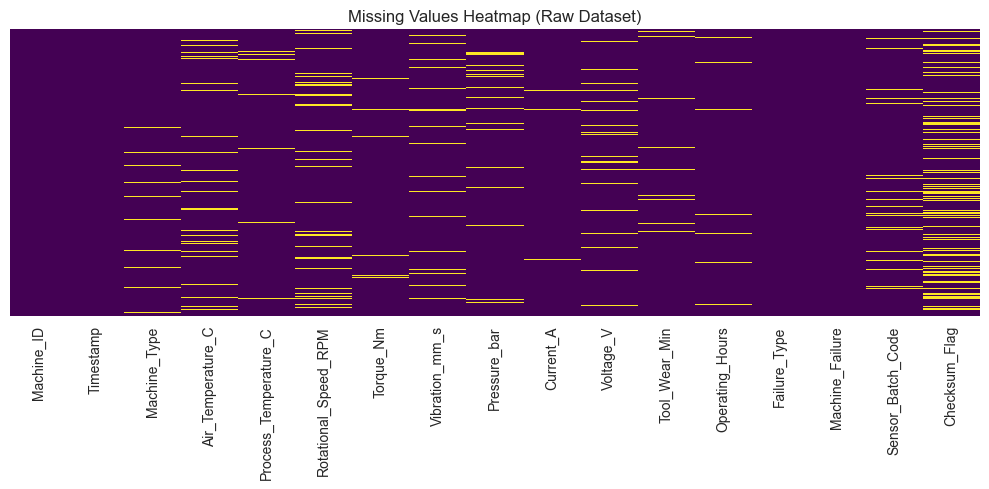

In [14]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Raw Dataset)')
plt.tight_layout()
plt.show()


## 2.7 Duplicate Records Check

In [16]:
duplicate_count = df.duplicated().sum()
print(f"Number of fully duplicate rows: {duplicate_count}")
print(f"Percentage of duplicate rows: {duplicate_count/len(df)*100:.2f}%")

df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)


Number of fully duplicate rows: 101
Percentage of duplicate rows: 1.01%


,Machine_ID,Timestamp,Machine_Type,Air_Temperature_C,Process_Temperature_C,Rotational_Speed_RPM,Torque_Nm,Vibration_mm_s,Pressure_bar,Current_A,Voltage_V,Tool_Wear_Min,Operating_Hours,Failure_Type,Machine_Failure,Sensor_Batch_Code,Checksum_Flag
1994,CMP-1002,2024-02-21 02:47:00,Compressor,20.41,31.93,1500.0,45.53,0.771,5.79,11.28,395.7,101.4,8856.5,No Failure,0,BATCH_9031,OK
5260,CMP-1002,2024-02-21 02:47:00,Compressor,20.41,31.93,1500.0,45.53,0.771,5.79,11.28,395.7,101.4,8856.5,No Failure,0,BATCH_9031,OK
4068,CMP-1002,2024-02-23 17:26:00,Compressor,26.16,35.45,1556.0,47.01,0.946,5.99,13.78,406.6,183.1,11471.7,No Failure,0,BATCH_1117,NaN
5208,CMP-1002,2024-02-23 17:26:00,Compressor,26.16,35.45,1556.0,47.01,0.946,5.99,13.78,406.6,183.1,11471.7,No Failure,0,BATCH_1117,NaN
1783,CMP-1002,2024-05-19 06:41:00,Compressor,24.53,34.97,1590.0,38.38,2.477,6.04,16.16,406.7,230.1,12183.7,No Failure,0,BATCH_9329,OK
8687,CMP-1002,2024-05-19 06:41:00,Compressor,24.53,34.97,1590.0,38.38,2.477,6.04,16.16,406.7,230.1,12183.7,No Failure,0,BATCH_9329,OK
342,CMP-1007,2024-01-06 14:58:00,Compressor,24.54,34.50,1743.0,53.54,2.314,5.35,18.61,395.9,157.4,15072.2,No Failure,0,BATCH_2102,OK
3934,CMP-1007,2024-01-06 14:58:00,Compressor,24.54,34.50,1743.0,53.54,2.314,5.35,18.61,395.9,157.4,15072.2,No Failure,0,BATCH_2102,OK
7218,CMP-1012,2024-03-20 11:47:00,Compressor,35.02,49.89,1432.0,49.97,3.019,8.67,13.83,438.6,35.3,10475.6,Heat Dissipation Failure,1,BATCH_1982,NaN
7409,CMP-1012,2024-03-20 11:47:00,Compressor,35.02,49.89,1432.0,49.97,3.019,8.67,13.83,438.6,35.3,10475.6,Heat Dissipation Failure,1,BATCH_1982,NaN


## 2.8 Target Variable Distribution — Machine_Failure

Machine_Failure distribution:
                 Count  Percentage
Machine_Failure                   
0                 8901       89.01
1                 1099       10.99


C:\Users\jamee\AppData\Local\Temp\ipykernel_27112\2275780368.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Machine_Failure', data=df, ax=ax[0], palette='Set2')
C:\Users\jamee\AppData\Local\Temp\ipykernel_27112\2275780368.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Healthy (0)', 'Failed (1)'])


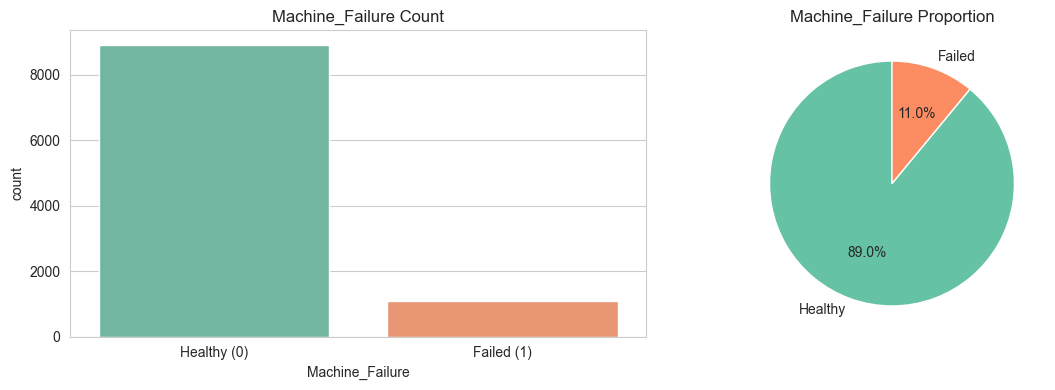

In [17]:
failure_counts = df['Machine_Failure'].value_counts()
failure_pct = df['Machine_Failure'].value_counts(normalize=True) * 100

print("Machine_Failure distribution:")
print(pd.DataFrame({'Count': failure_counts, 'Percentage': failure_pct.round(2)}))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='Machine_Failure', data=df, ax=ax[0], palette='Set2')
ax[0].set_title('Machine_Failure Count')
ax[0].set_xticklabels(['Healthy (0)', 'Failed (1)'])

ax[1].pie(failure_counts, labels=['Healthy', 'Failed'], autopct='%1.1f%%',
          colors=sns.color_palette('Set2'), startangle=90)
ax[1].set_title('Machine_Failure Proportion')
plt.tight_layout()
plt.show()


## 2.9 Failure Type Distribution

C:\Users\jamee\AppData\Local\Temp\ipykernel_27112\4078331505.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Failure_Type', data=df, order=order, palette='mako')


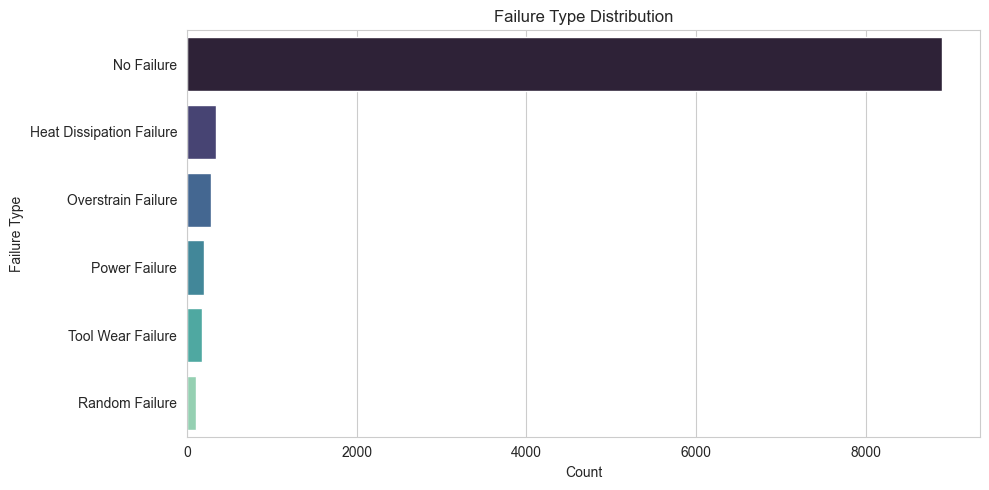

In [18]:
plt.figure(figsize=(10, 5))
order = df['Failure_Type'].value_counts().index
sns.countplot(y='Failure_Type', data=df, order=order, palette='mako')
plt.title('Failure Type Distribution')
plt.xlabel('Count')
plt.ylabel('Failure Type')
plt.tight_layout()
plt.show()


## 2.10 Data Understanding — Observations

Based on the exploration above, document the key findings before moving to cleaning, for example:

- Total records and columns in the raw dataset
- Presence of missing values across specific sensor columns
- Presence of duplicate rows
- Class imbalance in `Machine_Failure` (failures are the minority class)
- Irrelevant/administrative columns identified (e.g. `Sensor_Batch_Code`, `Checksum_Flag`) that carry no engineering meaning and are candidates for removal
- Sensor value ranges appear consistent with realistic industrial operating conditions


---
# STEP 3: Data Cleaning

Goal: Handle missing values, remove duplicates, correct data types, remove irrelevant columns, and validate data ranges to produce a clean, analysis-ready dataset.


## 3.1 Remove Irrelevant / Non-Predictive Columns

In [19]:
# Columns identified during Data Understanding as administrative / non-predictive
irrelevant_columns = ['Sensor_Batch_Code', 'Checksum_Flag']

df.drop(columns=[c for c in irrelevant_columns if c in df.columns], inplace=True)

print(f"Removed columns: {irrelevant_columns}")
print(f"Shape after removing irrelevant columns: {df.shape}")


Removed columns: ['Sensor_Batch_Code', 'Checksum_Flag']
Shape after removing irrelevant columns: (10000, 15)


## 3.2 Convert Data Types

In [20]:
# Convert Timestamp to proper datetime type
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Ensure categorical columns are typed as 'category' for memory efficiency
for col in ['Machine_ID', 'Machine_Type', 'Failure_Type']:
    df[col] = df[col].astype('category')

# Ensure Machine_Failure is integer (0/1)
df['Machine_Failure'] = pd.to_numeric(df['Machine_Failure'], errors='coerce')

df.dtypes


Machine_ID                     category
Timestamp                datetime64[ns]
Machine_Type                   category
Air_Temperature_C               float64
Process_Temperature_C           float64
Rotational_Speed_RPM            float64
Torque_Nm                       float64
Vibration_mm_s                  float64
Pressure_bar                    float64
Current_A                       float64
Voltage_V                       float64
Tool_Wear_Min                   float64
Operating_Hours                 float64
Failure_Type                   category
Machine_Failure                   int64
dtype: object

## 3.3 Remove Duplicate Records

In [21]:
before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]

print(f"Rows before removing duplicates: {before}")
print(f"Rows after removing duplicates: {after}")
print(f"Duplicate rows removed: {before - after}")


Rows before removing duplicates: 10000
Rows after removing duplicates: 9894
Duplicate rows removed: 106


## 3.4 Handle Missing Values

Strategy:
- **Numerical sensor columns** → impute using the **median** grouped by `Machine_Type` (preserves realistic per-machine-type sensor ranges, and is robust to outliers/failure spikes)
- **Categorical columns** (`Machine_Type`) → impute using the **mode**
- **Timestamp** → drop rows with missing timestamps (cannot be reliably imputed for time-series sensor data)


In [22]:
# Recheck missing values after column removal and dedup
missing_before = df.isnull().sum()
missing_before[missing_before > 0]


Machine_Type              490
Air_Temperature_C         806
Process_Temperature_C     135
Rotational_Speed_RPM     1024
Torque_Nm                 130
Vibration_mm_s            413
Pressure_bar              748
Current_A                  97
Voltage_V                 676
Tool_Wear_Min             271
Operating_Hours           213
dtype: int64

In [23]:
numerical_cols = ['Air_Temperature_C', 'Process_Temperature_C', 'Rotational_Speed_RPM',
                   'Torque_Nm', 'Vibration_mm_s', 'Pressure_bar', 'Current_A',
                   'Voltage_V', 'Tool_Wear_Min', 'Operating_Hours']

# Impute numerical columns using median grouped by Machine_Type
for col in numerical_cols:
    df[col] = df.groupby('Machine_Type', observed=True)[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Fallback: fill any remaining NaNs (e.g. if a whole group was NaN) with overall median
    df[col] = df[col].fillna(df[col].median())

print("Numerical missing values after imputation:")
print(df[numerical_cols].isnull().sum())


Numerical missing values after imputation:
Air_Temperature_C        0
Process_Temperature_C    0
Rotational_Speed_RPM     0
Torque_Nm                0
Vibration_mm_s           0
Pressure_bar             0
Current_A                0
Voltage_V                0
Tool_Wear_Min            0
Operating_Hours          0
dtype: int64


In [24]:
# Impute categorical Machine_Type with mode (if any missing)
if df['Machine_Type'].isnull().sum() > 0:
    mode_value = df['Machine_Type'].mode()[0]
    df['Machine_Type'] = df['Machine_Type'].fillna(mode_value)

print("Machine_Type missing values after imputation:", df['Machine_Type'].isnull().sum())


Machine_Type missing values after imputation: 0


In [25]:
# Drop rows with missing/invalid Timestamp (cannot be safely imputed)
rows_before = df.shape[0]
df.dropna(subset=['Timestamp'], inplace=True)
rows_after = df.shape[0]

print(f"Rows dropped due to missing Timestamp: {rows_before - rows_after}")


Rows dropped due to missing Timestamp: 0


In [26]:
# Final missing value check
final_missing = df.isnull().sum()
print("Remaining missing values per column:")
print(final_missing[final_missing > 0] if final_missing.sum() > 0 else "No missing values remaining.")


Remaining missing values per column:
No missing values remaining.


## 3.5 Validate and Correct Sensor Value Ranges

In [27]:
# Define realistic engineering bounds for each sensor to catch invalid/corrupted readings
valid_ranges = {
    'Air_Temperature_C':      (0, 60),
    'Process_Temperature_C':  (0, 80),
    'Rotational_Speed_RPM':   (0, 5000),
    'Torque_Nm':              (0, 150),
    'Vibration_mm_s':         (0, 20),
    'Pressure_bar':           (0, 20),
    'Current_A':              (0, 50),
    'Voltage_V':              (300, 500),
    'Tool_Wear_Min':          (0, 300),
    'Operating_Hours':        (0, 25000),
}

range_violations = {}
for col, (low, high) in valid_ranges.items():
    invalid_count = ((df[col] < low) | (df[col] > high)).sum()
    range_violations[col] = invalid_count

violations_df = pd.DataFrame.from_dict(range_violations, orient='index', columns=['Out_of_Range_Count'])
violations_df


,Out_of_Range_Count
Air_Temperature_C,0
Process_Temperature_C,0
Rotational_Speed_RPM,0
Torque_Nm,0
Vibration_mm_s,0
Pressure_bar,0
Current_A,0
Voltage_V,19
Tool_Wear_Min,0
Operating_Hours,0


In [28]:
# Cap out-of-range values to the nearest valid boundary (clipping) instead of dropping rows
for col, (low, high) in valid_ranges.items():
    df[col] = df[col].clip(lower=low, upper=high)

print("Sensor values clipped to realistic engineering ranges.")


Sensor values clipped to realistic engineering ranges.


## 3.6 Standardize Categorical Text Values

In [29]:
# Strip whitespace and standardize casing for categorical/text columns
for col in ['Machine_ID', 'Failure_Type']:
    df[col] = df[col].astype(str).str.strip()

df['Machine_Type'] = df['Machine_Type'].astype(str).str.strip().str.title()

# Re-cast back to category dtype after cleaning
for col in ['Machine_ID', 'Machine_Type', 'Failure_Type']:
    df[col] = df[col].astype('category')

print("Categorical text values standardized.")


Categorical text values standardized.


## 3.7 Consistency Check — Machine_Failure vs Failure_Type

In [30]:
# A healthy machine (Machine_Failure = 0) should always have Failure_Type = 'No Failure', and vice versa
inconsistent = df[
    ((df['Machine_Failure'] == 0) & (df['Failure_Type'] != 'No Failure')) |
    ((df['Machine_Failure'] == 1) & (df['Failure_Type'] == 'No Failure'))
]

print(f"Inconsistent Machine_Failure / Failure_Type records found: {len(inconsistent)}")
inconsistent.head()


Inconsistent Machine_Failure / Failure_Type records found: 0


,Machine_ID,Timestamp,Machine_Type,Air_Temperature_C,Process_Temperature_C,Rotational_Speed_RPM,Torque_Nm,Vibration_mm_s,Pressure_bar,Current_A,Voltage_V,Tool_Wear_Min,Operating_Hours,Failure_Type,Machine_Failure


In [31]:
# Correct any inconsistencies: trust Machine_Failure as the ground-truth label
df.loc[(df['Machine_Failure'] == 0) & (df['Failure_Type'] != 'No Failure'), 'Failure_Type'] = 'No Failure'
df.loc[(df['Machine_Failure'] == 1) & (df['Failure_Type'] == 'No Failure'), 'Machine_Failure'] = 1

print("Consistency check complete.")


Consistency check complete.


## 3.8 Reset Index and Final Duplicate Check

In [32]:
# Remove any duplicates introduced during cleaning, then reset index
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Final duplicate count: {df.duplicated().sum()}")
print(f"Final dataset shape: {df.shape}")


Final duplicate count: 0
Final dataset shape: (9893, 15)


## 3.9 Before vs After Cleaning Summary

In [33]:
summary = pd.DataFrame({
    'Metric': ['Rows', 'Columns', 'Missing Values', 'Duplicate Rows'],
    'Before Cleaning': [
        df_raw.shape[0],
        df_raw.shape[1],
        df_raw.isnull().sum().sum(),
        df_raw.duplicated().sum()
    ],
    'After Cleaning': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})
summary


,Metric,Before Cleaning,After Cleaning
0,Rows,10000,9893
1,Columns,17,15
2,Missing Values,8296,0
3,Duplicate Rows,101,0


In [34]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9893 entries, 0 to 9892
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Machine_ID             9893 non-null   category      
 1   Timestamp              9893 non-null   datetime64[ns]
 2   Machine_Type           9893 non-null   category      
 3   Air_Temperature_C      9893 non-null   float64       
 4   Process_Temperature_C  9893 non-null   float64       
 5   Rotational_Speed_RPM   9893 non-null   float64       
 6   Torque_Nm              9893 non-null   float64       
 7   Vibration_mm_s         9893 non-null   float64       
 8   Pressure_bar           9893 non-null   float64       
 9   Current_A              9893 non-null   float64       
 10  Voltage_V              9893 non-null   float64       
 11  Tool_Wear_Min          9893 non-null   float64       
 12  Operating_Hours        9893 non-null   float64       
 13  Fai

In [35]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
Timestamp,9893,2024-03-30 06:48:17.381987328,2024-01-01 01:26:00,2024-02-14 06:51:00,2024-03-30 05:06:00,2024-05-14 03:06:00,2024-06-28 23:25:00,NaN
Air_Temperature_C,9893.0,25.633195,16.55,24.0,25.44,26.94,41.63,2.829827
Process_Temperature_C,9893.0,35.704015,25.93,33.64,35.43,37.31,55.83,3.424784
Rotational_Speed_RPM,9893.0,1542.959921,864.0,1448.0,1541.0,1642.0,2250.0,167.309374
Torque_Nm,9893.0,40.932779,4.83,34.04,40.43,47.04,106.13,11.113621
Vibration_mm_s,9893.0,2.611504,0.003,1.933,2.539,3.173,11.861,1.14947
Pressure_bar,9893.0,5.541928,0.01,4.5,5.5,6.54,14.79,1.715543
Current_A,9893.0,12.013416,0.0,9.77,12.01,14.21,29.34,3.544057
Voltage_V,9893.0,414.969595,311.6,407.9,415.1,421.9,500.0,14.419035
Tool_Wear_Min,9893.0,135.737673,0.0,74.3,137.45,198.1,260.0,73.851688


## 3.10 Save the Cleaned Dataset

In [36]:
df.to_csv('predictive_maintenance_cleaned.csv', index=False)
print("Cleaned dataset saved as 'predictive_maintenance_cleaned.csv'")
print(f"Final shape: {df.shape}")


Cleaned dataset saved as 'predictive_maintenance_cleaned.csv'
Final shape: (9893, 15)


---
## Summary

- **Step 2 (Data Understanding):** Explored dataset shape, data types, statistical summaries, missing values, duplicates, and target class distribution.
- **Step 3 (Data Cleaning):** Removed irrelevant columns, corrected data types, removed duplicate rows, imputed missing values (median per `Machine_Type` for sensors, mode for categoricals), validated and clipped sensor readings to realistic engineering ranges, standardized categorical text, resolved label inconsistencies, and saved the cleaned dataset.

**Next Notebook:** `02_Feature_Engineering.ipynb`
